# Laboratory methods: experiments, measurements and uncertainties
## Experiment no. 3 - Darcy flow through a porous medium

**Your name(s):*Fateme for Test* 

**Date:*31.03.2026* 

---
## 1) Objective - Describe the objective of this experiment in your own words (max 150 words).

## 2) Experimental Setup (max 200 words)

## 3) Procedure - Briefly describe the procedure used to collect the data (max 200 words).

## 4) Data collection and storage
Enter paired measurements of imposed flow rate and measured pressure drop.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng()

# pump "ELENA"
# Enter your measured volume in [cm3], time in s and flow in RPM
V = 100
time = [70,38,25,20,17,15,12]
Q = [40,70,110,140,170,200,240]
Q = np.array(Q, dtype=float)
time = np.array(time, dtype=float)
# actual flow rate in [cm3/s]
QA = (V / time)

# conversion factor C (cm3/s per RPM)
C = QA/Q
c = np.mean(C)
print(f"Convertion factor c = {c:.3f} cm3/s per RPM")
df = pd.DataFrame({"Measured flow rate, [cm3/s]": QA, "conversion factor, [cm3/s per RPM]": C})
df

Convertion factor c = 0.035 cm3/s per RPM


,"Measured flow rate, [cm3/s]","conversion factor, [cm3/s per RPM]"
0,1.428571,0.035714
1,2.631579,0.037594
2,4.000000,0.036364
3,5.000000,0.035714
4,5.882353,0.034602
5,6.666667,0.033333
6,8.333333,0.034722


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng()

#location of Manometers in m
L1 = 
L2 = 
L3 = 
L4 = 
# radius of column in [cm]
R = 3
Area = np.pi * R**2
# gravity, density and dynamic viscosity in kg m s
rho = 
g = 
mu = 

# Enter your measured flow data below in [RPM]
flow = []
flow = np.array(flow, dtype=float)
# flow rate converted from RPM into cm3/s
Q = flow * c
N = len(flow)
# Darcy velocity in m/s
q = Q / Area / 100


# Enter your hydraulic head measurements in [cm]
h1 = []
h2 = []
h3 = []
h4 = []
h1 = np.array(h1, dtype=float)
h2 = np.array(h2, dtype=float)
h3 = np.array(h3, dtype=float)
h4 = np.array(h4, dtype=float)

# convert length from [cm] to [m]
h1 = h1 / 100
h2 = h2 / 100
h3 = h3 / 100
h4 = h4 / 100

gradh1 = (h2 - h1) / (L2 - L1)
gradh2 = (h3 - h2) / (L3 - L2)
gradh3 = (h4 - h3) / (L4 - L3)
gradh4 = (h4 - h2) / (L4 - L2)

assert Q.size == h1.size, "Flow and pressure arrays must be the same length"
assert Q.size == h2.size, "Flow and pressure arrays must be the same length"
assert Q.size == h3.size, "Flow and pressure arrays must be the same length"
assert Q.size == h4.size, "Flow and pressure arrays must be the same length"
assert Q.size >= 3, "Enter at least 3 data points"

df = pd.DataFrame({"Darcy velocity, [m/s]": q,"∇h1, [-]": gradh1,"∇h2, [-]": gradh2,"∇h3, [-]": gradh3,"∇h4, [-]": gradh4})
df

,"Darcy velocity, [m/s]","∇h1, [-]","∇h2, [-]","∇h3, [-]","∇h4, [-]"
0,0.000501,-0.058824,-0.06250,-0.06250,-0.062500
1,0.000877,-0.105882,-0.09375,-0.10000,-0.096875
2,0.001379,-0.158824,-0.15000,-0.15000,-0.150000
3,0.001880,-0.217647,-0.23750,-0.19375,-0.215625
4,0.002256,-0.258824,-0.27500,-0.23750,-0.256250
5,0.002757,-0.305882,-0.33125,-0.28750,-0.309375
6,0.003008,-0.300000,-0.35000,-0.31250,-0.331250


## 5) Show results


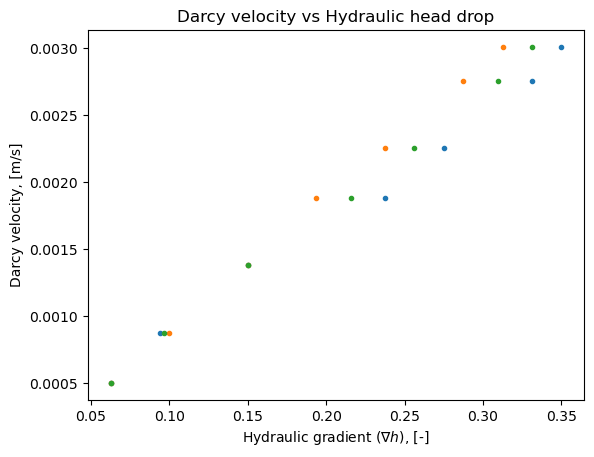

In [3]:
plt.figure()
plt.plot(- gradh1,q,'.')
plt.plot(- gradh2,q,'.')
plt.plot(- gradh3,q,'.')
plt.plot(- gradh4,q,'.')
plt.ylabel(r"Darcy velocity, [m/s]")
plt.xlabel(r"Hydraulic gradient ($\nabla h$), [-]")
plt.title(r"Darcy velocity vs Hydraulic head drop")
plt.grid(False)
plt.show()

## 6) Data analysis

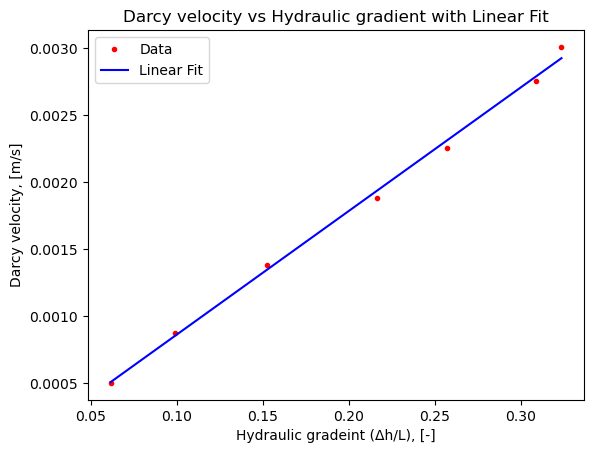

Experimental uncertainty sigmaY = 0.00005
A = -0.00006 m/s +- 0.00004 m/s
K = 0.00923 m/s + - 0.00019 m/s


,Hydraulic gradient [-],Darcy velocity [m/s],Hydraulic gradient squared [-],Velocity by gradient [m/s]
0,0.06158,0.000501,0.003792,0.000031
1,0.09913,0.000877,0.009826,0.000087
2,0.15221,0.001379,0.023167,0.000210
3,0.21613,0.001880,0.046712,0.000406
4,0.25689,0.002256,0.065994,0.000580
5,0.30850,0.002757,0.095173,0.000851
6,0.32344,0.003008,0.104612,0.000973


In [4]:
# Fit a linear model (Darcy's law): q = - K grad(h)
# Linear regression using NumPy only (JupyterLite compatible)

import numpy as np
import matplotlib.pyplot as plt

gradh = (gradh1+gradh2+gradh3+gradh4)/4

x = -gradh
y = q

# sample size
N = len(x)
# compute the parameters A and B of y = A + Bx
x2 = x**2
xy = x*y

A = (np.sum(x2) * np.sum(y) - np.sum(x) * np.sum(xy)) / (N * np.sum(x2) - (np.sum(x)**2))
B = (N * np.sum(xy) - np.sum(x) * np.sum(y)) / (N * np.sum(x2) - (np.sum(x))**2)

sigY = np.sqrt(1/N * np.sum((y - A - B*x)**2))
dA = sigY * np.sqrt((np.sum(x2)) / (N * np.sum(x2) - (np.sum(x)**2)))
dB = sigY * np.sqrt(N / (N * np.sum(x2) - (np.sum(x)**2)))

xx = np.linspace(np.min(x),np.max(x),30)
Y = A + B*xx

plt.figure(1)
plt.plot(-gradh,q,'r.',label="Data")
plt.plot(xx,Y,'b',label="Linear Fit")
plt.ylabel("Darcy velocity, [m/s]")
plt.xlabel("Hydraulic gradeint (Δh/L), [-]")
plt.title("Darcy velocity vs Hydraulic gradient with Linear Fit")
plt.legend()
plt.grid(False)
plt.show()

# permeability
k = B * mu / (rho * g) * 10**12

print(f"Experimental uncertainty sigmaY = {sigY:.5f}")
print(f"A = {A:.5f} m/s +- {dA:.5f} m/s")
print(f"K = {B:.5f} m/s + - {dB:.5f} m/s")

# create dataframe
df = pd.DataFrame({
    "Hydraulic gradient [-]": x,
    "Darcy velocity [m/s]": y,
    "Hydraulic gradient squared [-]": x2,
    "Velocity by gradient [m/s]": xy
})

# optional: round values for nicer display
df = df.round({
    "Hydraulic gradient [-]": 5,
    "Darcy velocity [m/s]": 7,
    "Hydraulic gradient squared [-]": 8,
    "Velocity by gradient [m/s]": 8
})
df

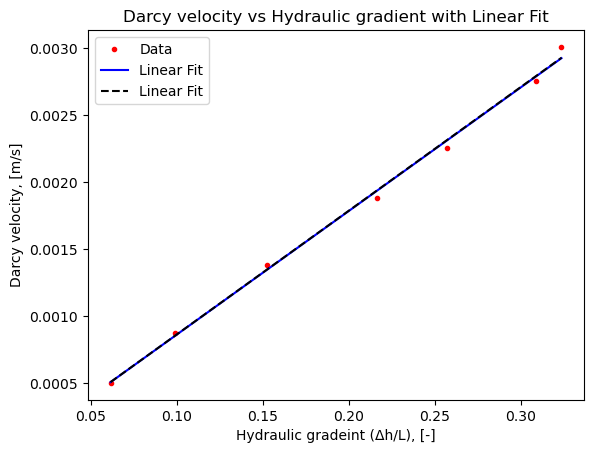

A = -0.0000613 m/s +- 0.0000422 m/s
K = 0.0092300 m/s + - 0.0001887 m/s
Kozeny-Carman prediction K = 0.0092393 m/s
Meas. permeability k = 837.4 darcy + - 17.1 darcy
CK predicted permeability k = 838.2 darcy


In [5]:
# Fit a linear model (Darcy's law): q = - K grad(h)
# Linear regression using NumPy only (JupyterLite compatible)

import numpy as np
import matplotlib.pyplot as plt

# Enter your system physical properties [m],[s],[kg]
dg = 
phi = 0.38

# KC formula prediction
K_KC = dg**2 / (180 * mu) * phi**3 / (1 - phi)**2 * rho * g

Y2 = A + K_KC*xx

plt.figure(1)
plt.plot(-gradh,q,'r.',label="Data")
plt.plot(xx,Y,'b',label="Linear Fit")
plt.plot(xx,Y2,'k--',label="Linear Fit")
plt.ylabel("Darcy velocity, [m/s]")
plt.xlabel("Hydraulic gradeint (Δh/L), [-]")
plt.title("Darcy velocity vs Hydraulic gradient with Linear Fit")
plt.legend()
plt.grid(False)
plt.show()

# permeability in darcy (1 darcy = 10^-12 m2)
k = B * mu / (rho * g) * 10**12
kKC = K_KC * mu / (rho * g) * 10**12

print(f"A = {A:.7f} m/s +- {dA:.7f} m/s")
print(f"K = {B:.7f} m/s + - {dB:.7f} m/s")
print(f"Kozeny-Carman prediction K = {K_KC:.7f} m/s")
print("===========") 
print(f"Meas. permeability k = {k:.1f} darcy + - {dB/B*k:.1f} darcy")
print(f"CK predicted permeability k = {kKC:.1f} darcy")


## 7) results discussion: comment on the items below
- Is the relationship between the data you collected (Darcy velocity and hydraulic gradient) linear? Motivate in terms of residuals and measurement uncertainty.
- The measured value for the Hydraulic conductivity is consistent with the prediction of the KC formula?
- How the Hydraulic conductivity varies with the grain size?
- How much is the estimate medium permeability (in darcy!!)?

---
### IMPORTANT: Before closing the browser
Go to **File → Download → Notebook (.ipynb)** to save your work.
